Run the following code once to get the dataframe:

In [42]:
from PullData import pull_data_from_supabase
import pandas as pd
import seaborn  as sns
import matplotlib.pyplot as plt

df = pull_data_from_supabase()

print(df.info())


feature_cols = ["learning_rate","batch_size","buffer_size","hidden_units","num_layers","time_horizon","beta","gamma","lambd","max_steps"]
target_cols = ["final_10_percent_reward_mean","late_phase_std"]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2261 entries, 0 to 2260
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   run_id                        2261 non-null   object 
 1   learning_rate                 2261 non-null   float64
 2   batch_size                    2261 non-null   int64  
 3   buffer_size                   2261 non-null   int64  
 4   hidden_units                  2261 non-null   int64  
 5   num_layers                    2261 non-null   int64  
 6   time_horizon                  2261 non-null   int64  
 7   beta                          2261 non-null   float64
 8   gamma                         2261 non-null   float64
 9   lambd                         2261 non-null   float64
 10  final_10_percent_reward_mean  2261 non-null   float64
 11  mean_reward                   2261 non-null   float64
 12  max_reward                    2261 non-null   float64
 13  min

### Features:
- learning_rate 
- batch_size 
- buffer_size 
- hidden_units 
- num_layers 
- time_horizon 
- beta 
- gamma 
- lambd 
- max_steps 

### Targets:
- final_10_percent_reward_mean
- late_phase_std

## Tasks:
1) Dataset Overview (Person A)
- Count total rows
- Count rows where error_occurred = true 
- Count rows where convergence_detected = true 
- List columns with missing values and counts 

Deliverable: table of counts

In [39]:
#your code here
total_records = len(df)
total_error_records = (df['error_occurred'] == True).sum()
total_records_converged = (df['convergence_detected'] == True).sum()
columns_with_nulls = df.columns[df.isna().any()].tolist()
null_columns_count = len(columns_with_nulls)


overview_table = pd.DataFrame({
    'total_records': [total_records],
    'total_error_records': [total_error_records],
    'total_records_converged': [total_records_converged],
    'columns_with_nulls_count': [null_columns_count],
    'columns_with_nulls_list': [', '.join(columns_with_nulls) if columns_with_nulls else 'None']
})

display(overview_table.style
    .set_caption('Dataset Overview ')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', "#000000"), ('color', 'white')]}
    ])
    .hide(axis="index")
)

total_records,total_error_records,total_records_converged,columns_with_nulls_count,columns_with_nulls_list
2261,0,2261,2,"config_path, error_message"


2) Feature Distribution (Person C)
- Plot normal Histogram for: hidden_units, num_layers, time_horizon, gamma, lambd, max_steps
- Plot Histogram with Log Scale for: learning_rate, batch_size, buffer_size, and beta
- x-axis: value of the feature
- y-axis: count/frequency

Deliverable: 6 normal histograms, 4 histograms with log scale

In [ ]:
#your code here

3. Target Distribution (Person C)
- Plot histogram for each target
  - x-axis: should be ranges of values (bins)
  - y-axis: count/frequency
- Plot boxplot for each target:
  - x-axis: also should be ranges of values 

- This is my personal idea: you can create a 2x2 grid. First row contains 2 histograms, Second row contains 2 boxplots. So that we can easily compare between histogram and boxplot

Deliverable: 2 histograms, 2 boxplots

In [ ]:
#your code here

4. Feature vs Target (Person B)
- To see how every feature affects the agent's success.
- For each feature:
    - Plot a scatter vs `final_10_percent_reward_mean`
    - Plot a scatter vs `late_phase_std`
    - x-axis: should be the feature
    - y-axis: should be the target
- Note: We often have **Overplotting**. This happens when many runs use the exact same hyperparameter value, causing the dots to stack on top of each other into one solid blob. The fix: Setting an `alpha` value

Deliverable: 2 scatter plots for each feature (10 features x 2 targets = 20 plots in total)


In [ ]:
#your code here

5. Feature Correlation (Person A)
- This heatmap should visualize the correlation between all features
- Compute correlation of matrix of all features
- Then visualze by heatmap

The heatmap should look like this Exmaple: 
| | lr | batch | buffer | hidden | layers | time_horizon | beta | gamma | lambda | max_step |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **lr** | 1.00 | 0.01 | -0.02 | 0.10 | 0.05 | ... |... |... |... |... |... |
| **batch** | 0.01 | 1.00 | 0.80 | 0.20 | 0.10 | ... |... |... |... |... |
| **buffer** | -0.02 | 0.80 | 1.00 | 0.15 | 0.05 | ... |... |... |... |... |
|**...**| ... | ... | ... | ... | ... | ... | ... | ... | ... | ... |

Deliverable: 1 heatmap

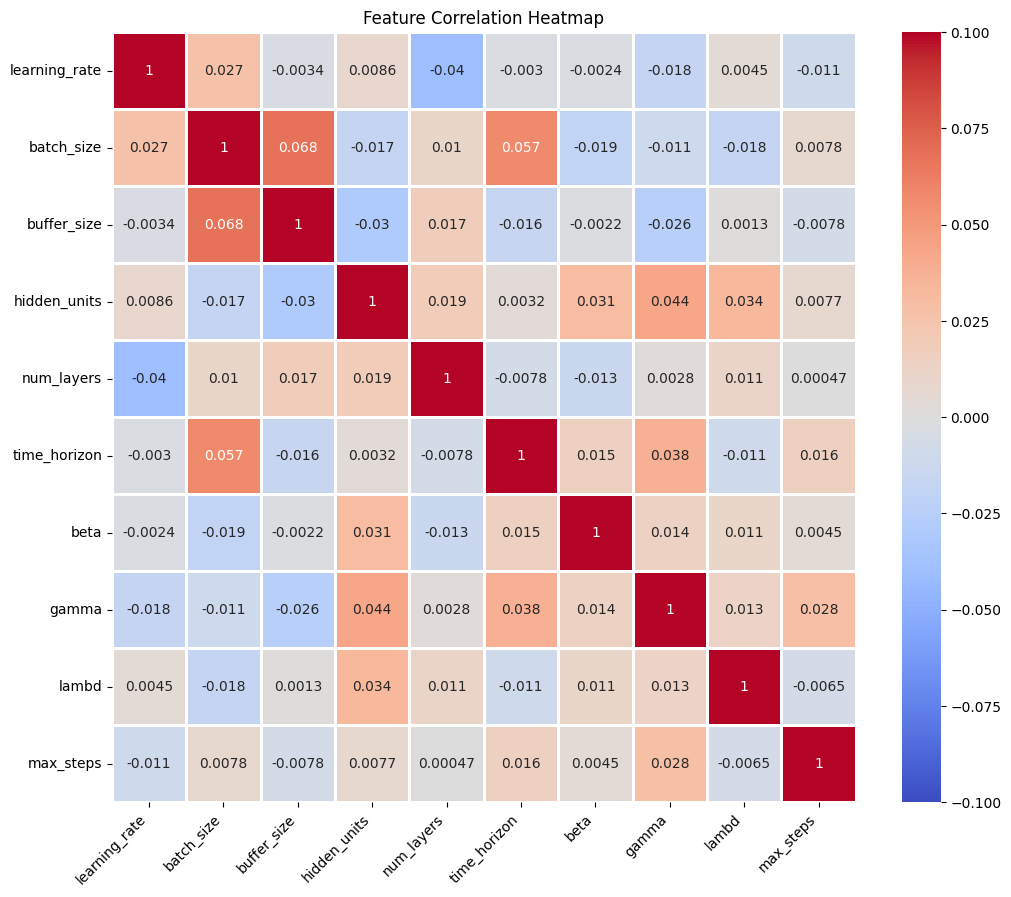

In [ ]:
#your code here

feature_df = df[feature_cols]
feature_corr_df= feature_df.corr()

plt.figure(figsize=(12, 10))

feature_heatmap =sns.heatmap(feature_corr_df, annot=True, cmap='coolwarm', vmin=-0.1, vmax=0.1,linewidths= 1 ,linecolor='white', center=0)
feature_heatmap.set_xticklabels(feature_heatmap.get_xticklabels(), rotation=45, ha='right')

plt.title("Feature Correlation Heatmap")
plt.show()

6. Performace vs Stability (Person B)
- To show trade-off between Performance (`final_10_percent_reward_mean`) and Stability (`late_phase_std`)
- Plot a scatter plot:
    - x-axis: `late_phase_std`
    - y-axis: `final_10_percent_reward_mean`

Deliverable: 1 Scatter plot

In [ ]:
#your code here